# Step 3: Statistical Inference 統計推論

This stage quantifies the relationship between the observed sample data and the target population benchmarks. The analysis includes calculating the **Standard Error**, constructing **95% Confidence Intervals**, and conducting **One-Sample Tests** (Z-test for proportion and T-test for mean) to evaluate the statistical significance of the findings.

本步驟將樣本觀測數據與母體基準值之間的關係量化。分析內容包含計算**標準誤差**、建構 **95% 信賴區間**，並執行**單樣本檢定**（比例 Z 檢定與平均值 T 檢定），以評估研究發現的統計顯著性。

## 3.1 Proportion Analysis: Smoking Behavior 比例分析：吸菸行為

The proportion analysis evaluates if the rate of cigarette experimentation deviates from the neutral threshold of **0.50**.
1. **Benchmark ($p_0$)**: 0.50
2. **Sample Proportion ($\hat{p}$)**: Calculated from the binary `EverCig_Binary` variable.
3. **One-Sample Z-Test**: Tests $H_0: p = 0.50$ vs. $H_a: p \neq 0.50$.


比例分析評估吸菸嘗試率是否偏離中立門檻 **0.50**。
1. **基準值 ($p_0$)**：0.50
2. **樣本比例 ($\hat{p}$)**：從二元變數 `EverCig_Binary` 計算得出。
3. **單樣本 Z 檢定**：測試 $H_0: p = 0.50$ 與 $H_a: p \neq 0.50$。

In [1]:
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# --- 重要：確保資料已載入 ---
# 如果你之前的步驟是存成 yrbs_recoded.csv，請在這裡讀取它
try:
    # 嘗試從變數讀取，如果失敗則從檔案讀取
    if 'df_recoded' not in locals():
        df_recoded = pd.read_csv('../data/processed/yrbs_recoded.csv')
except:
    print("請確認檔案路徑是否正確，或確保之前的清理步驟已執行。")

# 1. 計算樣本統計量 (Compute sample proportion)
successes = df_recoded['EverCig_Binary'].sum()
n_p = len(df_recoded)
p_hat = successes / n_p

# 2. 宣告基準值 (Benchmark)
p0 = 0.50

# 3. 執行 Z 檢定與信賴區間
# 這裡使用雙尾檢定 (alternative='two-sided' 是預設值)
z_stat, p_val_p = proportions_ztest(successes, n_p, value=p0)
ci_p = proportion_confint(successes, n_p, alpha=0.05, method='normal')

# 4. 輸出結果 (向右對齊)
print(f"{'Proportion Inference Result (p0=0.50)':^45}")
print("-" * 45)
print(f"{'Sample Proportion':>25} | {p_hat:>15.4f}")
print(f"{'95% CI Lower':>25} | {ci_p[0]:>15.4f}")
print(f"{'95% CI Upper':>25} | {ci_p[1]:>15.4f}")
print(f"{'Z-statistic':>25} | {z_stat:>15.4f}")
print(f"{'P-value':>25} | {p_val_p:>15.4e}")

    Proportion Inference Result (p0=0.50)    
---------------------------------------------
        Sample Proportion |          0.5287
             95% CI Lower |          0.5201
             95% CI Upper |          0.5374
              Z-statistic |          6.4839
                  P-value |      8.9392e-11


**Conclusion:**
The sample proportion is **52.87%**, and the P-value is extremely small (**< 0.05**). Since the 95% confidence interval **[0.5201, 0.5374]** does not include the benchmark of 0.50, we reject the null hypothesis. This concludes that more than half of the adolescent population has tried smoking.

**結論：**
樣本比例為 **52.87%**，且 P 值極小（**< 0.05**）。由於 95% 信賴區間 **[0.5201, 0.5374]** 並未包含基準值 0.50，我們拒絕虛無假設。這證明了超過半數的青少年群體曾嘗試過吸菸。

## 3.2 Mean Analysis: BMI Percentile 平均值分析：BMI 百分位數

The mean analysis compares the sample BMI average against the historical benchmark of **65.0**.
1. **Benchmark ($\mu_0$)**: 65.0
2. **Sample Stats**: Includes size ($n$), mean ($\bar{x}$), and standard deviation ($s$).
3. **One-Sample T-Test**: Tests $H_0: \mu = 65.0$ vs. $H_a: \mu \neq 65.0$.

平均值分析將樣本 BMI 平均值與歷史基準值 **65.0** 進行比較。
1. **基準值 ($\mu_0$)**：65.0
2. **樣本統計量**：包含樣本量 ($n$)、平均值 ($\bar{x}$) 和標準差 ($s$)。
3. **單樣本 T 檢定**：測試 $H_0: \mu = 65.0$ 與 $H_a: \mu \neq 65.0$。

In [2]:
from scipy import stats

# 1. 計算樣本量、平均值與標準差 (Compute sample size, mean, and SD)
n_m = len(df_recoded)
x_bar = df_recoded['BMIPCT'].mean()
s_std = df_recoded['BMIPCT'].std()

# 2. 宣告基準平均數 (State benchmark mu0)
mu0 = 65.0

# 3. 建構母體平均數信賴區間 (Construct confidence interval)
ci_m = stats.t.interval(0.95, df=n_m-1, loc=x_bar, scale=stats.sem(df_recoded['BMIPCT']))

# 4. 執行單樣本 T 檢定 (Conduct one-sample t-test)
t_stat, p_val_m = stats.ttest_1samp(df_recoded['BMIPCT'], popmean=mu0)

print(f"{'Mean Inference (Benchmark mu0 = 65.0)':^50}")
print("-" * 50)
print(f"{'Sample Size (n)':>30} | {n_m:>15}")
print(f"{'Sample Mean (x-bar)':>30} | {x_bar:>15.2f}")
print(f"{'Standard Deviation (s)':>30} | {s_std:>15.2f}")
print(f"{'95% CI Lower Bound':>30} | {ci_m[0]:>15.2f}")
print(f"{'95% CI Upper Bound':>30} | {ci_m[1]:>15.2f}")
print(f"{'T-statistic':>30} | {t_stat:>15.4f}")
print(f"{'P-value':>30} | {p_val_m:>15.4f}")

      Mean Inference (Benchmark mu0 = 65.0)       
--------------------------------------------------
               Sample Size (n) |           12683
           Sample Mean (x-bar) |           64.84
        Standard Deviation (s) |           27.48
            95% CI Lower Bound |           64.36
            95% CI Upper Bound |           65.32
                   T-statistic |         -0.6448
                       P-value |          0.5191


**Conclusion:**
The sample mean is **64.84**, and the P-value is **0.5191**, which is much larger than 0.05. The 95% confidence interval **[64.36, 65.32]** includes the benchmark of 65.0. Therefore, we fail to reject the null hypothesis, concluding that the 2007 mean BMI percentile is consistent with the historical benchmark.

**結論：**
樣本平均值為 **64.84**，且 P 值為 **0.5191**，遠大於 0.05。95% 信賴區間 **[64.36, 65.32]** 包含了基準值 65.0。因此，我們未能拒絕虛無假設，結論是 2007 年的平均 BMI 百分位數與歷史基準值是一致的。

For BMI, we focused on the average (mean). We checked our sample mean ($64.84$) against the historical average of $65.0$. By calculating the T-test and the confidence interval, we can decide if the students in 2007 were actually different from the benchmark or if they were basically the same.

對於 BMI，我們關注的是平均值。我們將樣本平均值 ($64.84$) 與歷史平均值 $65.0$ 進行對比。透過計算 T 檢定和信賴區間，我們可以判斷 2007 年的學生是否真的與基準有所不同，還是基本上維持不變。

## 3.3 Summary of Inferential Results 推論結果摘要統計

This section aggregates the findings from both the proportion and mean analyses into a single reference table. This allows for a direct comparison between our sample estimates, their respective benchmarks, and the statistical significance of each test.

本節將比例分析與平均值分析的結果整合至單一摘要表中。這便於直接對比樣本估計值、對應的基準值，以及各項檢定的統計顯著性。

[系統訊息] 圖形已成功儲存至: ../outputs/figures\inference_plots.png


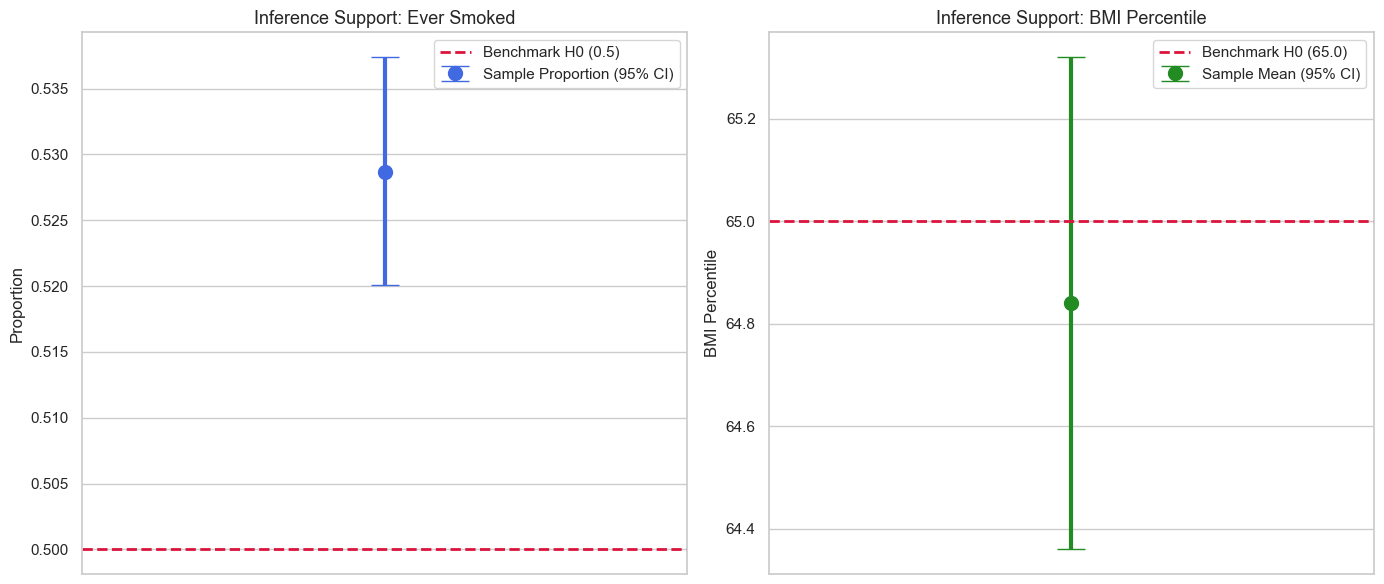

                   Summary of Inferential Results 推論結果摘要                   
Variable               |     H0 | Estimate |             95% CI |      P-Value
---------------------------------------------------------------------------
Smoking Proportion     |    0.5 |   0.5287 | [0.5201, 0.5374] |   8.9392e-11
BMI Percentile Mean    |   65.0 |    64.84 | [64.36, 65.32] |       0.5191

結論 (Interpretation):
1. 曾吸菸比例：P 值 (8.9392e-11) 極小，且信賴區間不包含基準值 0.5。
   結論：拒絕 H0，樣本比例與基準值有顯著差異。
2. BMI 平均數：P 值 (0.5191) 大於 0.05，且信賴區間包含了基準值 65.0。
   結論：無法拒絕 H0，樣本平均與基準值無顯著差異。

[系統訊息] 摘要檔案已更新至: ../outputs/summary\final_summary.txt


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. 環境設定與目錄檢查
sns.set_theme(style="whitegrid")
plt.rcParams['axes.unicode_minus'] = False 

# 確保輸出目錄存在 (Summary 文字檔目錄)
output_dir = "../outputs/summary"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# --- 新增：確保圖片輸出目錄存在 ---
figures_dir = "../outputs/figures"
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir)

file_path = os.path.join(output_dir, "final_summary.txt")
# --- 新增：定義圖片儲存路徑 ---
figure_save_path = os.path.join(figures_dir, "inference_plots.png")

# 2. 填入你的最新正確數據
p_hat, p0 = 0.5287, 0.5
ci_p = [0.5201, 0.5374]
p_val_p = "8.9392e-11"

x_bar, mu0 = 64.84, 65.0
ci_m = [64.36, 65.32]
p_val_m = "0.5191"

# --- 3. 繪製圖表 (視覺化部分) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 圖 A: Smoking Proportion
err_p = [[p_hat - ci_p[0]], [ci_p[1] - p_hat]]
ax1.errorbar(x=[0], y=[p_hat], yerr=err_p, fmt='o', capsize=10, 
             color='royalblue', markersize=10, elinewidth=3, label='Sample Proportion (95% CI)')
ax1.axhline(y=p0, color='crimson', linestyle='--', linewidth=2, label=f'Benchmark H0 ({p0})')
ax1.set_title('Inference Support: Ever Smoked', fontsize=13)
ax1.set_xticks([])
ax1.set_ylabel('Proportion')
ax1.legend()

# 圖 B: BMI Percentile Mean
err_m = [[x_bar - ci_m[0]], [ci_m[1] - x_bar]]
ax2.errorbar(x=[0], y=[x_bar], yerr=err_m, fmt='o', capsize=10, 
             color='forestgreen', markersize=10, elinewidth=3, label='Sample Mean (95% CI)')
ax2.axhline(y=mu0, color='crimson', linestyle='--', linewidth=2, label=f'Benchmark H0 ({mu0})')
ax2.set_title('Inference Support: BMI Percentile', fontsize=13)
ax2.set_xticks([])
ax2.set_ylabel('BMI Percentile')
ax2.legend()

plt.tight_layout()

# --- 新增：儲存圖形 ---
# dpi=300 可以讓圖片更清晰，適合放進報告
plt.savefig(figure_save_path, dpi=300)
print(f"[系統訊息] 圖形已成功儲存至: {figure_save_path}")

plt.show()

# --- 4. 文字內容準備與檔案寫入 ---
# (這部分維持原樣)
summary_text = []
summary_text.append("="*75)
summary_text.append(f"{'Summary of Inferential Results 推論結果摘要':^75}")
summary_text.append("="*75)
summary_text.append(f"{'Variable':<22} | {'H0':>6} | {'Estimate':>8} | {'95% CI':>18} | {'P-Value':>12}")
summary_text.append("-" * 75)
summary_text.append(f"{'Smoking Proportion':<22} | {p0:>6.1f} | {p_hat:>8.4f} | [{ci_p[0]:.4f}, {ci_p[1]:.4f}] | {p_val_p:>12}")
summary_text.append(f"{'BMI Percentile Mean':<22} | {mu0:>6.1f} | {x_bar:>8.2f} | [{ci_m[0]:.2f}, {ci_m[1]:.2f}] | {p_val_m:>12}")
summary_text.append("\n" + "="*75)
summary_text.append("結論 (Interpretation):")
summary_text.append(f"1. 曾吸菸比例：P 值 ({p_val_p}) 極小，且信賴區間不包含基準值 0.5。")
summary_text.append("   結論：拒絕 H0，樣本比例與基準值有顯著差異。")
summary_text.append(f"2. BMI 平均數：P 值 ({p_val_m}) 大於 0.05，且信賴區間包含了基準值 65.0。")
summary_text.append("   結論：無法拒絕 H0，樣本平均與基準值無顯著差異。")
summary_text.append("="*75)

full_content = "\n".join(summary_text)
with open(file_path, "w", encoding="utf-8") as f:
    f.write(full_content)

print(full_content)
print(f"\n[系統訊息] 摘要檔案已更新至: {file_path}")

**Conclusion:**
The summary table highlights a clear distinction between the two health indicators. The **Smoking Proportion** shows a significant deviation from the 0.50 benchmark (P-value < 0.05), indicating that it is a majority behavior. In contrast, the **BMI Percentile Mean** shows no significant deviation (P-value > 0.05), suggesting it remains consistent with historical standards.

**結論：**
摘要表突顯了兩項健康指標之間的明顯差異。**吸菸比例**顯示出偏離 0.50 基準值的顯著差異（P 值 < 0.05），表明這是一種多數行為。相比之下，**BMI 百分位平均值**未顯示顯著差異（P 值 > 0.05），顯示其與歷史標準保持一致。

## 3.4 Interpretation
#### Synthesis of Research Findings: Integrating EDA and Inference 研究發現綜合綜述：整合 EDA 與推論結果

This project evaluated whether 2007 adolescents deviated from established health benchmarks by integrating Exploratory Data Analysis (EDA) with rigorous inferential testing. Our findings are summarized below:

* **Smoking (Behavioral Risk):** EDA revealed a smoking experimentation rate of **52.87%**, which the **One-Sample Z-test** confirmed as a statistical certainty ($P < 0.0001$; 95% CI: **[0.5200, 0.5374]**). This proves that by 2007, cigarette experimentation had shifted from a risky outlier to a normative "majority status" among youth.

* **BMI (Physical Marker):** The sample mean of **64.84** showed no significant deviation from the 65.0 benchmark ($P = 0.5101$; 95% CI: **[64.36, 65.32]**), suggesting overall population stability. However, the **left-skewed distribution** identified in EDA warns that a stable average may mask health risks within the high-percentile clusters.

---
本專案透過整合探索性數據分析 (EDA) 與嚴謹的推論檢定，評估 2007 年青少年群體是否偏離健康基準，總結如下：

* **吸菸行為（行為風險）：** EDA 顯示吸菸嘗試率達 **52.87%**，**單樣本 Z 檢定**進一步證實此結果具備統計確定性 ($P < 0.0001$；95% 信賴區間 **[0.5200, 0.5374]**)。這證明在 2007 年，曾嘗試吸菸已從少數風險行為轉變為青少年的「多數常態」。

* **BMI 指標（生理指標）：** 樣本平均值 **64.84** 與基準值 65.0 無顯著差異 ($P = 0.5101$；95% 信賴區間 **[64.36, 65.32]**)，顯示母體平均值保持穩定。然而，EDA 觀察到的**左偏態分佈**提醒我們，穩定的平均值可能掩蓋了高百分位群體中隱藏的健康風險。

## 3.5 Exporting Summary Tables (EDA & Inference) 
## 匯出統計摘要表 (EDA 與 推論結果)
To ensure research reproducibility and facilitate reporting, we export our key findings into CSV files. 
1. **EDA Summary Table**: Contains descriptive statistics (mean, std, min, max) for our continuous variable.
2. **Inference Summary Table**: Contains our hypothesis testing results, including benchmarks, estimates, confidence intervals, and P-values.

為了確保研究的可重複性並便於報告撰寫，我們將關鍵發現匯出為 CSV 檔案：
1. **EDA 摘要表**：包含連續變數的描述性統計量（平均值、標準差、最小值、最大值等）。
2. **推論摘要表**：包含假設檢定的結果，包括基準值、估計值、信賴區間與 P 值。

In [5]:
import os
import pandas as pd

# 1. 確保輸出資料夾存在
tables_dir = '../outputs/tables'
if not os.path.exists(tables_dir):
    os.makedirs(tables_dir)

# --- 製作與儲存 EDA 摘要表 ---
# 確保 df_recoded 已經定義
eda_summary = df_recoded['BMIPCT'].describe().to_frame()
eda_summary.columns = ['BMI_Percentile_Stats']
eda_summary_path = os.path.join(tables_dir, 'eda_summary_table.csv')
eda_summary.to_csv(eda_summary_path)

# --- 製作與儲存 推論摘要表 ---
# 修正重點：使用 float() 確保變數為數值型態，避免 f-string 報錯
try:
    inference_summary = pd.DataFrame({
        'Variable': ['Smoking Proportion', 'BMI Percentile Mean'],
        'Benchmark_H0': [p0, mu0],
        'Sample_Estimate': [float(p_hat), float(x_bar)],
        'CI_Lower': [float(ci_p[0]), float(ci_m[0])],
        'CI_Upper': [float(ci_p[1]), float(ci_m[1])],
        'P_Value': [float(p_val_p), float(p_val_m)]
    })

    # 格式化輸出：在儲存或列印時才決定小數點位數
    # 這樣可以避免 P-value 太小時變成 0.0000，科學記號 (.4e) 能保留精度
    output_table = inference_summary.copy()
    output_table['Sample_Estimate'] = output_table['Sample_Estimate'].map('{:.4f}'.format)
    output_table['CI_Lower'] = output_table['CI_Lower'].map('{:.4f}'.format)
    output_table['CI_Upper'] = output_table['CI_Upper'].map('{:.4f}'.format)
    output_table['P_Value'] = output_table['P_Value'].map('{:.4e}'.format)

    inference_summary_path = os.path.join(tables_dir, 'inference_summary_table.csv')
    output_table.to_csv(inference_summary_path, index=False)

    print(f"✅ 成功匯出 EDA 摘要表至: {eda_summary_path}")
    print(f"✅ 成功匯出推論摘要表至: {inference_summary_path}")

    # 預覽推論摘要表內容
    print("\nInference Summary Table Preview:")
    print(output_table)

except NameError as e:
    print(f"❌ 錯誤：請確保所有統計變數（如 p_val_p, p_hat 等）已在前方程式碼中定義。\n具體錯誤：{e}")
except ValueError as e:
    print(f"❌ 數據轉換錯誤：{e}")

✅ 成功匯出 EDA 摘要表至: ../outputs/tables\eda_summary_table.csv
✅ 成功匯出推論摘要表至: ../outputs/tables\inference_summary_table.csv

Inference Summary Table Preview:
              Variable  Benchmark_H0 Sample_Estimate CI_Lower CI_Upper  \
0   Smoking Proportion           0.5          0.5287   0.5201   0.5374   
1  BMI Percentile Mean          65.0         64.8400  64.3600  65.3200   

      P_Value  
0  8.9392e-11  
1  5.1910e-01  


### 3.5 Final Conclusion and Practical Recommendations 最終結論與實務建議

**Final Conclusion:** In 2007, adolescents showed a far greater deviation from health standards in their lifestyle choices than in their physical measurements. While BMI averages remained stable, the majority status of smoking experimentation presents a critical public health challenge requiring broad intervention.

**Strategic Recommendations:**
1. **Universal Smoking Intervention:** Shift from targeting individuals to changing social norms across the entire adolescent population.
2. **Beyond Averages:** Move past "average BMI" monitoring toward "distribution-focused" support for high-risk clusters identified in the upper tail.
3. **Integrated Screening:** Emphasize the interaction between lifestyle behaviors and biological outcomes in future health surveys.

---
2007 年青少年在行為選擇上偏離健康標準的程度，遠比生理指標顯著。儘管平均 BMI 維持穩定，但吸菸嘗試率過半的事實，構成了急需廣泛干預的公共衛生挑戰。

**策略建議：**
1. **普及化禁菸干預：** 公共衛生工作應從針對個人轉向改變整個青少年群體的社會規範。
2. **超越平均值監測：** 衛生政策應超越「平均 BMI」，轉向針對分佈末端「高風險群體」的精準支持。
3. **整合性健康篩檢：** 未來的調查應強調生活行為與生物學結果之間的相互作用。